In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')

In [2]:
import os
if os.path.exists('dataset.csv'):
    df = pd.read_csv('dataset.csv')
else:
    df = pd.read_csv(r"/kaggle/input/datasets/abhinavsharma005/car-price-dataset/dataset.csv")


In [3]:
df.head()

,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74


In [4]:
df.shape

(6019, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6019 entries, 0 to 6018
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         6019 non-null   int64  
 1   Name               6019 non-null   object 
 2   Location           6019 non-null   object 
 3   Year               6019 non-null   int64  
 4   Kilometers_Driven  6019 non-null   int64  
 5   Fuel_Type          6019 non-null   object 
 6   Transmission       6019 non-null   object 
 7   Owner_Type         6019 non-null   object 
 8   Mileage            6017 non-null   object 
 9   Engine             5983 non-null   object 
 10  Power              5983 non-null   object 
 11  Seats              5977 non-null   float64
 12  New_Price          824 non-null    object 
 13  Price              6019 non-null   float64
dtypes: float64(2), int64(3), object(9)
memory usage: 658.5+ KB


In [6]:
df.describe()

,Unnamed: 0,Year,Kilometers_Driven,Seats,Price
count,6019.000000,6019.000000,6.019000e+03,5977.000000,6019.000000
mean,3009.000000,2013.358199,5.873838e+04,5.278735,9.479468
std,1737.679967,3.269742,9.126884e+04,0.808840,11.187917
min,0.000000,1998.000000,1.710000e+02,0.000000,0.440000
25%,1504.500000,2011.000000,3.400000e+04,5.000000,3.500000
50%,3009.000000,2014.000000,5.300000e+04,5.000000,5.640000
75%,4513.500000,2016.000000,7.300000e+04,5.000000,9.950000
max,6018.000000,2019.000000,6.500000e+06,10.000000,160.000000


In [7]:
df.isnull().sum()

Unnamed: 0              0
Name                    0
Location                0
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 2
Engine                 36
Power                  36
Seats                  42
New_Price            5195
Price                   0
dtype: int64

In [8]:
(df.isnull().sum() / len(df)) * 100

Unnamed: 0            0.000000
Name                  0.000000
Location              0.000000
Year                  0.000000
Kilometers_Driven     0.000000
Fuel_Type             0.000000
Transmission          0.000000
Owner_Type            0.000000
Mileage               0.033228
Engine                0.598106
Power                 0.598106
Seats                 0.697790
New_Price            86.310018
Price                 0.000000
dtype: float64

In [9]:
# Drop columns
df.drop("Unnamed: 0", axis=1, inplace=True)
df.drop("New_Price", axis=1, inplace=True)

In [10]:
# Remove units
df["Mileage"] = df["Mileage"].str.replace(" kmpl", "", regex=False)
df["Mileage"] = df["Mileage"].str.replace(" km/kg", "", regex=False)
df["Engine"] = df["Engine"].str.replace(" CC", "", regex=False)
df["Power"] = df["Power"].str.replace(" bhp", "", regex=False)

# Convert to numeric
df["Mileage"] = pd.to_numeric(df["Mileage"], errors="coerce")
df["Engine"] = pd.to_numeric(df["Engine"], errors="coerce")
df["Power"] = pd.to_numeric(df["Power"], errors="coerce")

In [11]:
#Filling missing values
df["Mileage"].fillna(df["Mileage"].median(), inplace=True)
df["Engine"].fillna(df["Engine"].median(), inplace=True)
df["Power"].fillna(df["Power"].median(), inplace=True)

<Axes: xlabel='Seats', ylabel='Price'>

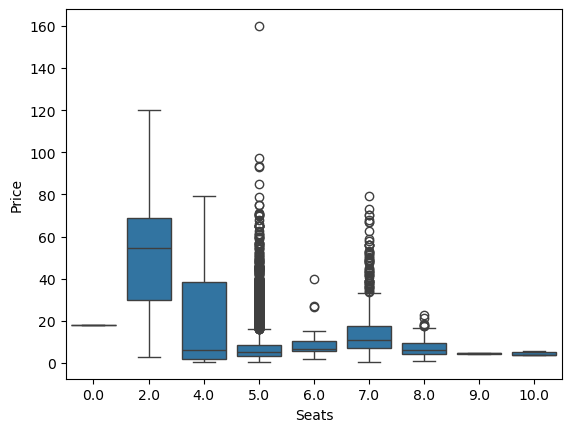

In [12]:
sns.boxplot(
    x="Seats",
    y="Price",
    data=df
)

In [13]:
df[df["Seats"] == 0]

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
3999,Audi A4 3.2 FSI Tiptronic Quattro,Hyderabad,2012,125000,Petrol,Automatic,First,10.5,3197.0,97.7,0.0,18.0


In [14]:
#treating 0 seat value as null
df.loc[df["Seats"] == 0, "Seats"] = np.nan
#filling 
df["Seats"] = df["Seats"].fillna(df["Seats"].median())

In [15]:
df[df["Mileage"] == 0]

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
14,Land Rover Freelander 2 TD4 SE,Pune,2012,85000,Diesel,Automatic,Second,0.0,2179.0,115.0,5.0,17.50
67,Mercedes-Benz C-Class Progressive C 220d,Coimbatore,2019,15369,Diesel,Automatic,First,0.0,1950.0,194.0,5.0,35.67
79,Hyundai Santro Xing XL,Hyderabad,2005,87591,Petrol,Manual,First,0.0,1086.0,97.7,5.0,1.30
194,Honda City 1.5 GXI,Ahmedabad,2007,60006,Petrol,Manual,First,0.0,1493.0,97.7,5.0,2.95
229,Ford Figo Diesel,Bangalore,2015,70436,Diesel,Manual,First,0.0,1498.0,99.0,5.0,3.60
...,...,...,...,...,...,...,...,...,...,...,...,...
5647,Toyota Qualis Fleet A3,Mumbai,2001,227000,Diesel,Manual,Fourth & Above,0.0,2446.0,97.7,8.0,2.20
5875,Mercedes-Benz C-Class Progressive C 220d,Ahmedabad,2019,4000,Diesel,Automatic,First,0.0,1950.0,194.0,5.0,35.00
5943,Mahindra Jeep MM 540 DP,Chennai,2002,75000,Diesel,Manual,First,0.0,2112.0,97.7,6.0,1.70
5972,Hyundai Santro Xing GL,Mumbai,2008,65000,Petrol,Manual,Second,0.0,1086.0,62.0,5.0,1.39


In [16]:
df[df["Mileage"] == 0][["Name", "Fuel_Type", "Year", "Engine", "Power", "Price"]].head(20)

,Name,Fuel_Type,Year,Engine,Power,Price
14,Land Rover Freelander 2 TD4 SE,Diesel,2012,2179.0,115.00,17.50
67,Mercedes-Benz C-Class Progressive C 220d,Diesel,2019,1950.0,194.00,35.67
79,Hyundai Santro Xing XL,Petrol,2005,1086.0,97.70,1.30
194,Honda City 1.5 GXI,Petrol,2007,1493.0,97.70,2.95
229,Ford Figo Diesel,Diesel,2015,1498.0,99.00,3.60
262,Hyundai Santro Xing XL,Petrol,2006,1086.0,97.70,1.75
307,Hyundai Santro Xing XL,Petrol,2006,1086.0,97.70,1.50
424,Volkswagen Jetta 2007-2011 1.9 L TDI,Diesel,2010,1968.0,97.70,5.45
443,Hyundai Santro GLS I - Euro I,Petrol,2012,1086.0,97.70,3.35
544,Mercedes-Benz New C-Class Progressive C 200,Petrol,2019,1950.0,181.43,38.99


In [17]:
# Replace invalid mileage with NaN
df.loc[df["Mileage"] == 0, "Mileage"] = np.nan

# Fill missing values
df["Mileage"] = df["Mileage"].fillna(df["Mileage"].median())

<Axes: xlabel='Price', ylabel='Count'>

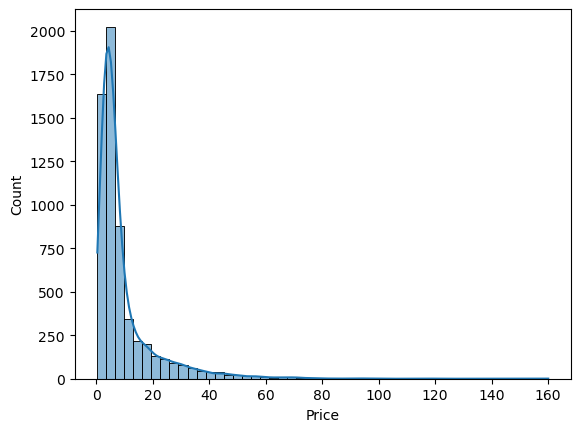

In [18]:
sns.histplot(df['Price'], bins = 50, kde = True)

<Axes: >

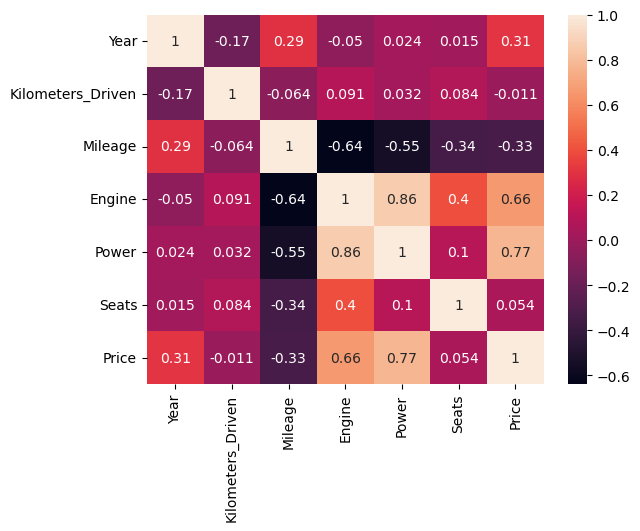

In [19]:
sns.heatmap(df.corr(numeric_only = True), annot = True)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30],
 [Text(0, 0, 'Maruti'),
  Text(1, 0, 'Hyundai'),
  Text(2, 0, 'Honda'),
  Text(3, 0, 'Audi'),
  Text(4, 0, 'Nissan'),
  Text(5, 0, 'Toyota'),
  Text(6, 0, 'Volkswagen'),
  Text(7, 0, 'Tata'),
  Text(8, 0, 'Land'),
  Text(9, 0, 'Mitsubishi'),
  Text(10, 0, 'Renault'),
  Text(11, 0, 'Mercedes-Benz'),
  Text(12, 0, 'BMW'),
  Text(13, 0, 'Mahindra'),
  Text(14, 0, 'Ford'),
  Text(15, 0, 'Porsche'),
  Text(16, 0, 'Datsun'),
  Text(17, 0, 'Jaguar'),
  Text(18, 0, 'Volvo'),
  Text(19, 0, 'Chevrolet'),
  Text(20, 0, 'Skoda'),
  Text(21, 0, 'Mini'),
  Text(22, 0, 'Fiat'),
  Text(23, 0, 'Jeep'),
  Text(24, 0, 'Smart'),
  Text(25, 0, 'Ambassador'),
  Text(26, 0, 'Isuzu'),
  Text(27, 0, 'ISUZU'),
  Text(28, 0, 'Force'),
  Text(29, 0, 'Bentley'),
  Text(30, 0, 'Lamborghini')])

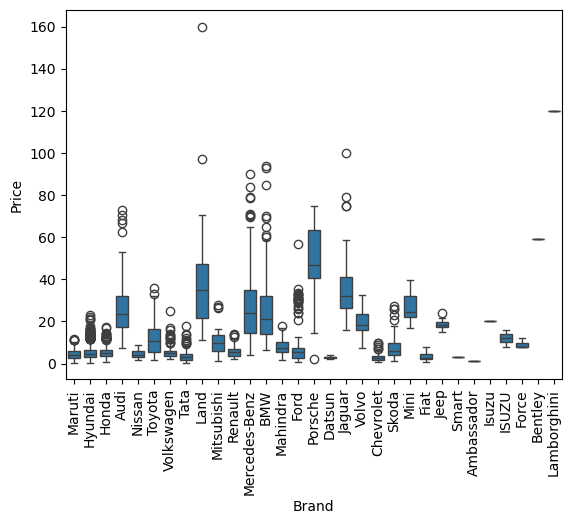

In [20]:
df["Brand"] = df["Name"].str.split().str[0]
df.drop("Name", axis=1, inplace=True)
sns.boxplot(
    x="Brand",
    y="Price",
    data=df
)

plt.xticks(rotation=90)

<Axes: xlabel='Fuel_Type', ylabel='Price'>

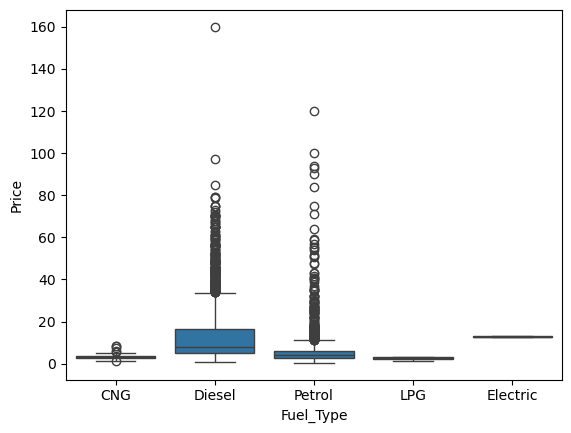

In [21]:
sns.boxplot(
    x="Fuel_Type",
    y="Price",
    data=df
)

<Axes: xlabel='Transmission', ylabel='Price'>

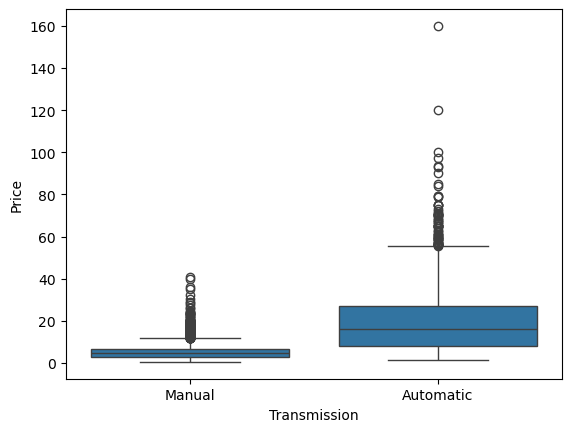

In [22]:
sns.boxplot(
    x="Transmission",
    y="Price",
    data=df
)

<Axes: xlabel='Mileage', ylabel='Price'>

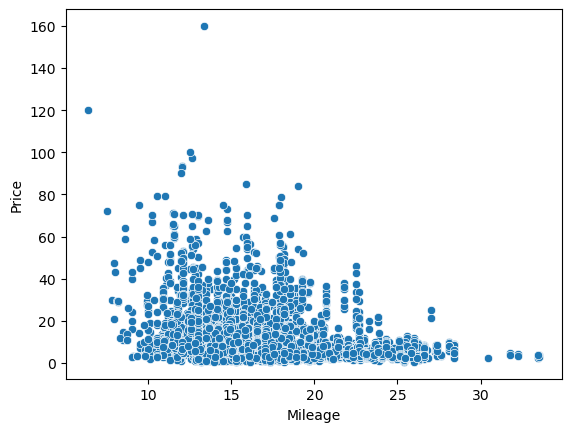

In [23]:
sns.scatterplot(data = df, x = 'Mileage', y = 'Price')

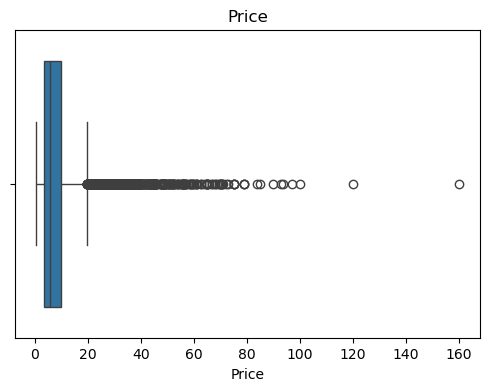

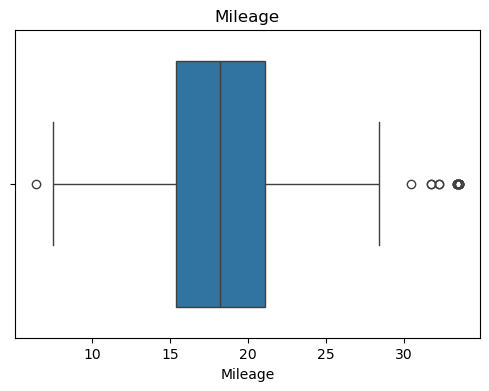

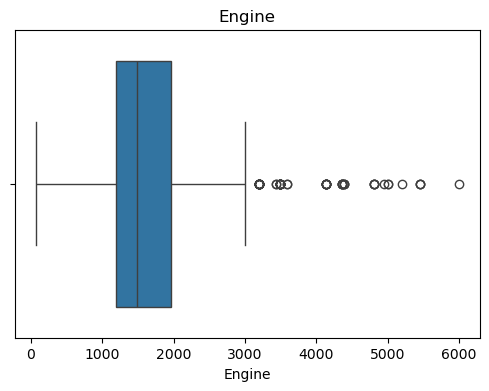

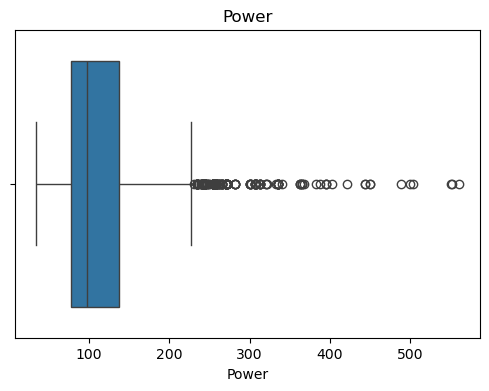

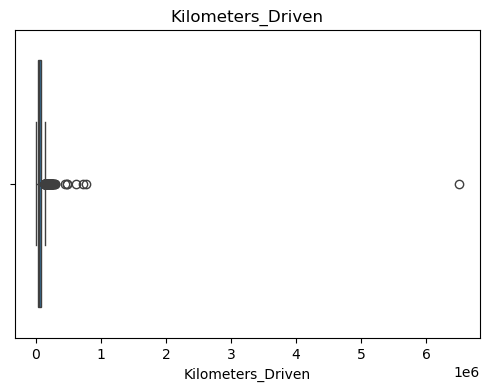

In [24]:
numeric_columns = [
    "Price",
    "Mileage",
    "Engine",
    "Power",
    "Kilometers_Driven"
]

for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [25]:
# Creating Input & Output Features
x = df.drop(columns=["Price"], axis=1)
y = df["Price"]

In [26]:
x

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Brand
0,Mumbai,2010,72000,CNG,Manual,First,26.60,998.0,58.16,5.0,Maruti
1,Pune,2015,41000,Diesel,Manual,First,19.67,1582.0,126.20,5.0,Hyundai
2,Chennai,2011,46000,Petrol,Manual,First,18.20,1199.0,88.70,5.0,Honda
3,Chennai,2012,87000,Diesel,Manual,First,20.77,1248.0,88.76,7.0,Maruti
4,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,Audi
...,...,...,...,...,...,...,...,...,...,...,...
6014,Delhi,2014,27365,Diesel,Manual,First,28.40,1248.0,74.00,5.0,Maruti
6015,Jaipur,2015,100000,Diesel,Manual,First,24.40,1120.0,71.00,5.0,Hyundai
6016,Jaipur,2012,55000,Diesel,Manual,Second,14.00,2498.0,112.00,8.0,Mahindra
6017,Kolkata,2013,46000,Petrol,Manual,First,18.90,998.0,67.10,5.0,Maruti


In [27]:
y

0        1.75
1       12.50
2        4.50
3        6.00
4       17.74
        ...  
6014     4.75
6015     4.00
6016     2.90
6017     2.65
6018     2.50
Name: Price, Length: 6019, dtype: float64

In [28]:
X_one_encode = pd.get_dummies(
    x,
    columns=[
        "Brand",
        "Location",
        "Fuel_Type",
        "Transmission",
        "Owner_Type"
    ],
    drop_first=True
)
X_one_encode

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Brand_Audi,Brand_BMW,Brand_Bentley,Brand_Chevrolet,...,Location_Mumbai,Location_Pune,Fuel_Type_Diesel,Fuel_Type_Electric,Fuel_Type_LPG,Fuel_Type_Petrol,Transmission_Manual,Owner_Type_Fourth & Above,Owner_Type_Second,Owner_Type_Third
0,2010,72000,26.60,998.0,58.16,5.0,False,False,False,False,...,True,False,False,False,False,False,True,False,False,False
1,2015,41000,19.67,1582.0,126.20,5.0,False,False,False,False,...,False,True,True,False,False,False,True,False,False,False
2,2011,46000,18.20,1199.0,88.70,5.0,False,False,False,False,...,False,False,False,False,False,True,True,False,False,False
3,2012,87000,20.77,1248.0,88.76,7.0,False,False,False,False,...,False,False,True,False,False,False,True,False,False,False
4,2013,40670,15.20,1968.0,140.80,5.0,True,False,False,False,...,False,False,True,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6014,2014,27365,28.40,1248.0,74.00,5.0,False,False,False,False,...,False,False,True,False,False,False,True,False,False,False
6015,2015,100000,24.40,1120.0,71.00,5.0,False,False,False,False,...,False,False,True,False,False,False,True,False,False,False
6016,2012,55000,14.00,2498.0,112.00,8.0,False,False,False,False,...,False,False,True,False,False,False,True,False,True,False
6017,2013,46000,18.90,998.0,67.10,5.0,False,False,False,False,...,False,False,False,False,False,True,True,False,False,False


In [29]:
from sklearn.preprocessing import StandardScaler

numerical_cols = [
    "Year",
    "Kilometers_Driven",
    "Mileage",
    "Engine",
    "Power",
    "Seats"
]

scaler = StandardScaler()

X_one_encode[numerical_cols] = scaler.fit_transform(
    X_one_encode[numerical_cols]
)

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_one_encode,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, np.log1p(y_train))


LinearRegression()

In [32]:
y_pred = np.expm1(model.predict(X_test))
y_pred


array([ 4.86336731, 10.39810213,  7.60178906, ...,  4.89983635,
        8.35234917,  2.3080846 ])

In [33]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("Baseline Linear Regression R² Score:", r2)

Baseline Linear Regression R² Score: 0.8065022260850665


In [34]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,     # number of trees
    max_depth=None,       # let trees grow fully
    random_state=42,

)

In [35]:
rf_model.fit(X_train,y_train)

RandomForestRegressor(random_state=42)

In [36]:
y_pred = rf_model.predict(X_test)
y_pred

array([ 5.7229, 12.9398,  7.9894, ...,  6.1955,  5.2464,  2.1451])

In [37]:
r2 = r2_score(y_test, y_pred)
print("Baseline Random Forest R² Score:", r2)

Baseline Random Forest R² Score: 0.8928370672382485
